In [14]:
import numpy as np
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import json

In [29]:
from azure.storage.blob import BlobServiceClient
import numpy as np
import io
import os

# Azure Storage account details
AZURE_STORAGE_CONNECTION_STRING = os.getenv("SONAR_STORAGE_KEY")
CONTAINER_NAME = "svmdata"

# Blob file names
BLOB_NAMES = {
    "embeddings": "embeddings_checkpoint-592000.npy",
    "labels": "labels_checkpoint-592000.npy"
}

# Initialize BlobServiceClient
blob_service_client = BlobServiceClient.from_connection_string(AZURE_STORAGE_CONNECTION_STRING)
container_client = blob_service_client.get_container_client(CONTAINER_NAME)

# Function to download and load .npy files
def load_npy_from_azure(blob_name):
    blob_client = container_client.get_blob_client(blob_name)
    blob_data = blob_client.download_blob().readall()
    npy_file = np.load(io.BytesIO(blob_data))  # Load numpy file from bytes
    return npy_file

# Load embeddings and labels
X = load_npy_from_azure(BLOB_NAMES["embeddings"])  # Features (embeddings)
y = load_npy_from_azure(BLOB_NAMES["labels"])      # Labels

# Print shape to verify
print("Feature matrix shape:", X.shape)  # (num_samples, embedding_dim)
print("Labels shape:", y.shape)          # (num_samples,)

Feature matrix shape: (38847, 768)
Labels shape: (38847,)


In [30]:
print("First sample (first 10 features):", X[0][:10])  # View first 10 values
print("Number of features per sample:", X.shape[1])

First sample (first 10 features): [ 0.7427885  -1.3101634   0.09983734  1.7290639  -0.8243641   0.7515901
  0.6445557  -0.2159761   0.20897408 -0.31135133]
Number of features per sample: 768


In [59]:
from azure.storage.blob import BlobServiceClient
import numpy as np
import io
from sklearn.model_selection import train_test_split

# Azure Storage account details
AZURE_STORAGE_CONNECTION_STRING = os.getenv("SONAR_STORAGE_KEY")
CONTAINER_NAME = "svmdata"

# Blob file names
BLOB_NAMES = {
    "embeddings": "embeddings_checkpoint-2072.npy",
    "labels": "labels_checkpoint-2072.npy"
}

# Initialize BlobServiceClient
blob_service_client = BlobServiceClient.from_connection_string(AZURE_STORAGE_CONNECTION_STRING)
container_client = blob_service_client.get_container_client(CONTAINER_NAME)

# Function to download and load .npy files
def load_npy_from_azure(blob_name):
    blob_client = container_client.get_blob_client(blob_name)
    blob_data = blob_client.download_blob().readall()
    return np.load(io.BytesIO(blob_data))  # Load numpy file from bytes

# Load embeddings and labels
X = load_npy_from_azure(BLOB_NAMES["embeddings"])  # Features (embeddings)
y = load_npy_from_azure(BLOB_NAMES["labels"])      # Labels

# Manually create the word-to-indices mapping (since word_mapping.json is missing)
word_occurrences = {
    "man": 11923,   # Label 1
    "vrouw": 9227,  # Label 0
    "broer": 1779,  # Label 1
    "zus": 1106     # Label 0
}

word_labels = {
    "man": 1,
    "vrouw": 0,
    "broer": 1,
    "zus": 0
}

# Create index mapping based on given information
word_to_indices = {}
start_index = 0
for word, count in word_occurrences.items():
    word_to_indices[word] = list(range(start_index, start_index + count))
    start_index += count

# Ensure train-test split maintains label balance & prevents data leakage
train_groups = []
test_groups = []

for word, indices in word_to_indices.items():
    train, test = train_test_split(indices, test_size=0.2, random_state=42, stratify=[word_labels[word]] * len(indices))
    train_groups.append(train)
    test_groups.append(test)

# Flatten the lists
train_indices = [idx for group in train_groups for idx in group]
test_indices = [idx for group in test_groups for idx in group]

# Ensure data is properly balanced
X_train, X_test = X[train_indices], X[test_indices]
y_train, y_test = y[train_indices], y[test_indices]

# Print shapes and check label balance
print(f"Training data shape: {X_train.shape}, Test data shape: {X_test.shape}")
print(f"Training label distribution: {np.bincount(y_train)}")
print(f"Testing label distribution: {np.bincount(y_test)}")

Training data shape: (19226, 768), Test data shape: (4809, 768)
Training label distribution: [ 3918 15308]
Testing label distribution: [ 974 3835]


In [60]:
# print an example of the first 10 training samples
print("First 10 training samples:")
print(X_train[:10])

First 10 training samples:
[[-0.5410887  -0.66746217  0.4229219  ... -0.16057037 -0.00935669
   0.91733706]
 [-1.2588003  -0.58031046 -0.55586964 ... -0.1084446   0.6220428
   0.690805  ]
 [-0.7504691  -0.5452216  -0.5139176  ...  0.1191026   0.6394086
   0.463213  ]
 ...
 [-0.41728285 -0.86294574 -0.4418071  ...  0.10692732  1.2324874
   0.65098846]
 [-0.5864268  -0.24221602  0.04482256 ...  0.05859308  1.410241
   0.5783146 ]
 [-0.9599617  -0.28860655  0.31984273 ...  0.23700406  1.1612573
   0.2666331 ]]


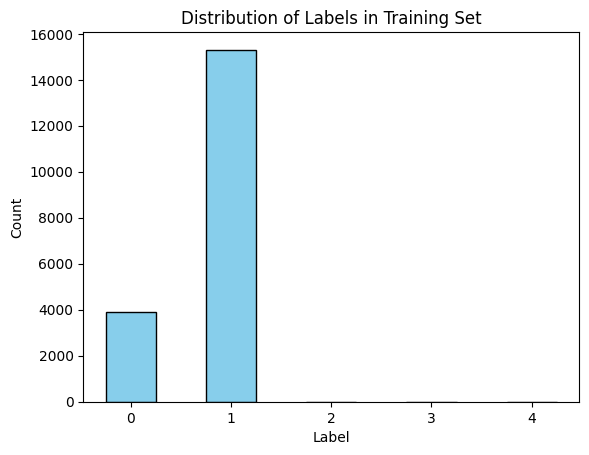

In [61]:
# Plot the distribution of labels in the training set
import matplotlib.pyplot as plt

plt.hist(y_train, bins=np.arange(0, 6) - 0.5, rwidth=0.5, align="mid", color="skyblue", edgecolor="black")
plt.xticks(range(5))
plt.xlabel("Label")
plt.ylabel("Count")
plt.title("Distribution of Labels in Training Set")
plt.show()

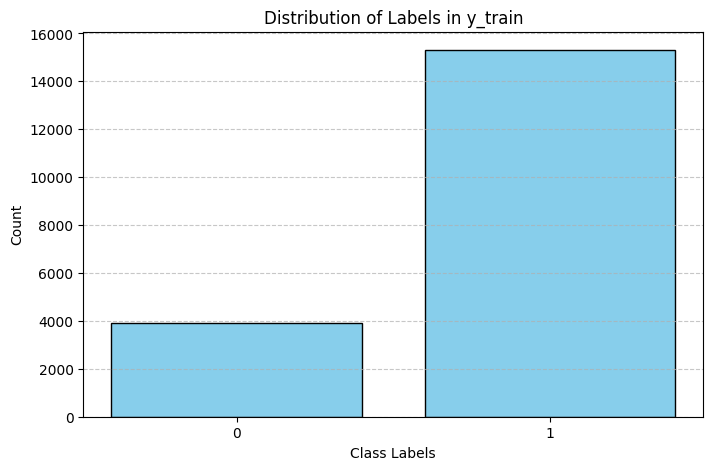

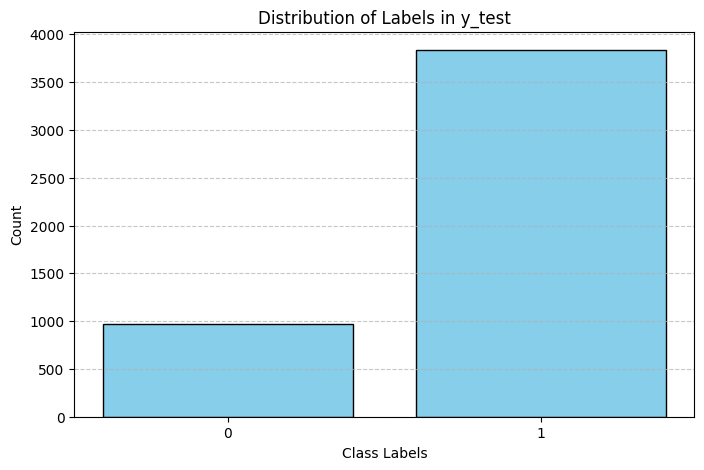

In [62]:
import matplotlib.pyplot as plt
import numpy as np

# Count occurrences of each class
classes, counts = np.unique(y_train, return_counts=True)

# Plot
plt.figure(figsize=(8, 5))
plt.bar(classes, counts, color='skyblue', edgecolor='black')

# Labels and title
plt.xlabel('Class Labels')
plt.ylabel('Count')
plt.title('Distribution of Labels in y_train')
plt.xticks(classes)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

# Count occurrences of each class
classes, counts = np.unique(y_test, return_counts=True)

# Plot
plt.figure(figsize=(8, 5))
plt.bar(classes, counts, color='skyblue', edgecolor='black')

# Labels and title
plt.xlabel('Class Labels')
plt.ylabel('Count')
plt.title('Distribution of Labels in y_test')
plt.xticks(classes)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

In [63]:
# Print the number of features per sample
print("Number of features per sample:", X_train.shape[1])

Number of features per sample: 768


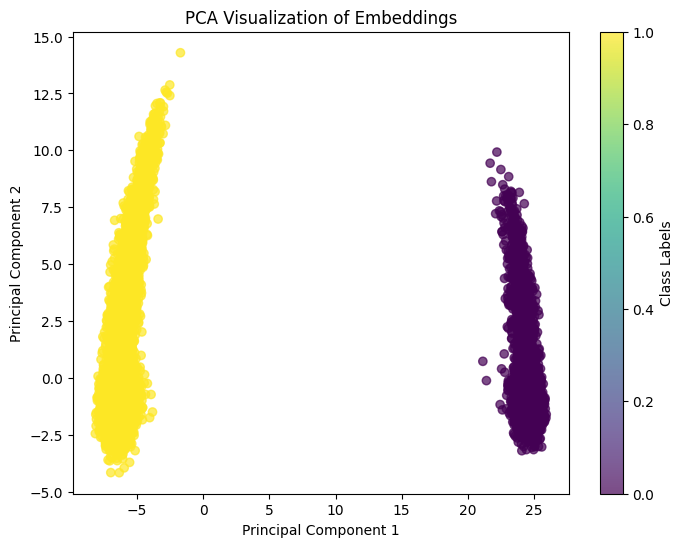

In [64]:
from sklearn.decomposition import PCA

# Apply PCA to reduce to 2 dimensions
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train)

# Scatter plot of PCA-reduced features
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_train, cmap='viridis', alpha=0.7)
plt.colorbar(scatter, label="Class Labels")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Visualization of Embeddings")
plt.show()

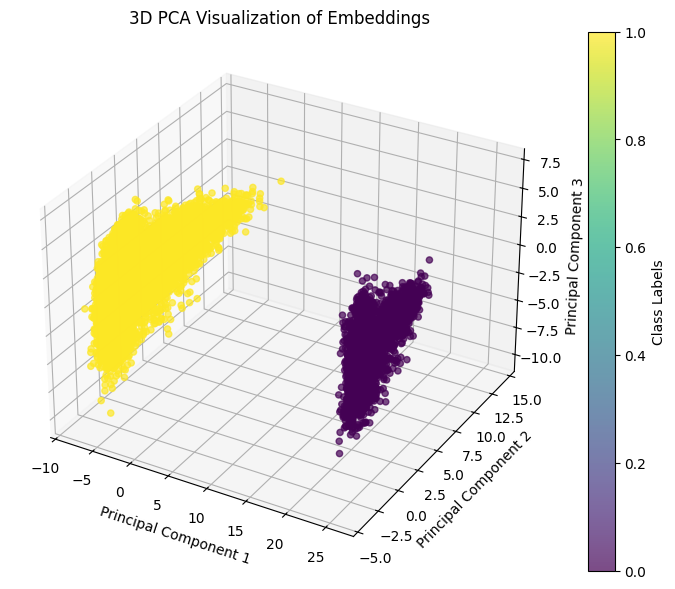

In [65]:
# Apply PCA to reduce to 3 dimensions
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_train)

# 3D Scatter plot of PCA-reduced features
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=y_train, cmap='viridis', alpha=0.7)

# Labels and color bar
ax.set_xlabel("Principal Component 1")
ax.set_ylabel("Principal Component 2")
ax.set_zlabel("Principal Component 3")
ax.set_title("3D PCA Visualization of Embeddings")
plt.colorbar(scatter, label="Class Labels")

# Show plot
plt.show()

In [66]:
# Initialize SVM classifier with linear kernel
svm_model = SVC(kernel="linear", C=1.0, random_state=42)

# Train the model
svm_model.fit(X_train, y_train)


SVC(kernel='linear', random_state=42)

In [67]:
# Make predictions
y_pred = svm_model.predict(X_test)

# Evaluate performance
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")

# Print detailed classification report
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 1.0
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       974
           1       1.00      1.00      1.00      3835

    accuracy                           1.00      4809
   macro avg       1.00      1.00      1.00      4809
weighted avg       1.00      1.00      1.00      4809



Text(0.5, 1.0, 'Confusion Matrix')

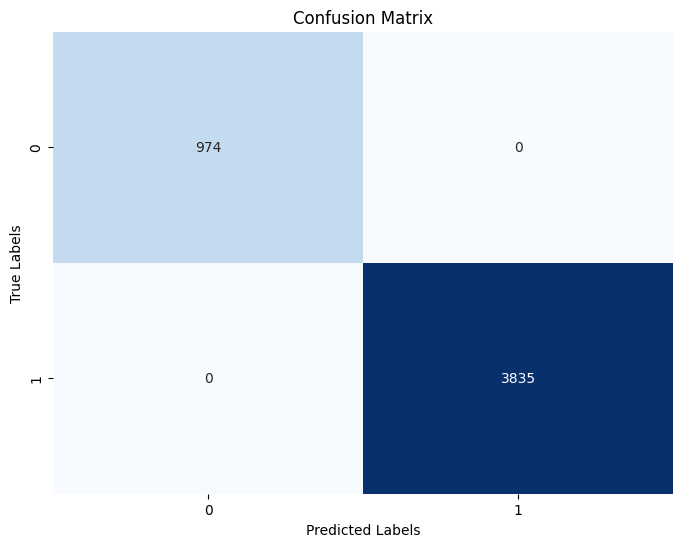

In [68]:
# Confusion matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Compute confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# Plot confusion matrix as heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes, cbar=False)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')


In [57]:
# Run svm again, but everytime with only one of the 768 features
accuracies = []

for i in range(X_train.shape[1]):
    # Select only one feature
    X_train_single = X_train[:, i].reshape(-1, 1)
    X_test_single = X_test[:, i].reshape(-1, 1)

    # Initialize SVM classifier
    svm_model = SVC(kernel="linear", C=1.0, random_state=42)

    # Train the model
    print(f"Training model with feature {i}")
    svm_model.fit(X_train_single, y_train)

    # Make predictions
    y_pred = svm_model.predict(X_test_single)

    # Evaluate performance
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Feature {i}: Accuracy: {accuracy}")
    accuracies.append(accuracy)

# Get the feature with the highest accuracy
best_feature = np.argmax(accuracies)
best_accuracy = accuracies[best_feature]

print(f"Best feature: {best_feature}, Accuracy: {best_accuracy}")

Training model with feature 0
Feature 0: Accuracy: 0.7974630900395092
Training model with feature 1
Feature 1: Accuracy: 0.827199001871491
Training model with feature 2
Feature 2: Accuracy: 0.8702432938240798
Training model with feature 3
Feature 3: Accuracy: 0.8423788729465586
Training model with feature 4
Feature 4: Accuracy: 0.7974630900395092
Training model with feature 5
Feature 5: Accuracy: 0.7974630900395092
Training model with feature 6
Feature 6: Accuracy: 0.7974630900395092
Training model with feature 7
Feature 7: Accuracy: 0.7974630900395092
Training model with feature 8
Feature 8: Accuracy: 0.7974630900395092
Training model with feature 9
Feature 9: Accuracy: 0.8750259929299231
Training model with feature 10
Feature 10: Accuracy: 0.8380120607194843
Training model with feature 11
Feature 11: Accuracy: 0.7974630900395092
Training model with feature 12
Feature 12: Accuracy: 0.7974630900395092
Training model with feature 13
Feature 13: Accuracy: 0.7974630900395092
Training mode

KeyboardInterrupt: 

In [49]:
# Get the 5 best features
top_features = np.argsort(accuracies)[::-1][:5]
top_accuracies = [accuracies[i] for i in top_features]

print(f"Top 5 features: {top_features}, Accuracies: {top_accuracies}")

Top 5 features: [563 494 646 570 246], Accuracies: [0.6529803709706465, 0.6389339095984152, 0.63713308121736, 0.634431838645777, 0.634071672969566]


In [ ]:
# Run SVM with the best features
X_train_best = X_train[:, best_feature].reshape(-1, 1)
X_test_best = X_test[:, best_feature].reshape(-1, 1)

# Initialize SVM classifier
svm_model = SVC(kernel="linear", C=1.0, random_state=42)

# Train the model
svm_model.fit(X_train_best, y_train)

# Make predictions
y_pred = svm_model.predict(X_test_best)

# Evaluate performance
accuracy = accuracy_score(y_test, y_pred)

print(f"accuracy with best features: {accuracy}")

accuracy with best features: 0.6529803709706465


In [51]:
# Run SVM with all but the best features
X_train_other = np.delete(X_train, best_feature, axis=1)
X_test_other = np.delete(X_test, best_feature, axis=1)

# Initialize SVM classifier
svm_model = SVC(kernel="linear", C=1.0, random_state=42)

# Train the model
svm_model.fit(X_train_other, y_train)

# Make predictions
y_pred = svm_model.predict(X_test_other)

# Evaluate performance
accuracy = accuracy_score(y_test, y_pred)

print(f"accuracy without best features: {accuracy}")

accuracy without best features: 0.9902755267423015
